# H-alpha high-contrast imaging with the WCC vs pointing jitter and Strehl ratio

**Question.** `halpha_hci_feasibility.ipynb` finds that PDS 70 b and c are detectable in the 2 nm H-alpha
filter within an hour *at the photon limit with an ideal PSF subtraction*. How does that hold up if the
delivered jitter is 0-20 mas (1σ per axis) and the Strehl ratio 1.0-0.7, and what does the PSF's
*stability* between science and reference frames cost?

**Two effects, treated separately.**
1. **Static PSF shape.** Jitter smears the Airy rings and a Strehl halo adds light at 4 Airy FWHM (~180 mas,
   right at PDS 70 b). Both change the stellar light in the planet aperture and therefore the photon-noise
   limit, and both lower the peak pixel and so lengthen the saturation-limited frame.
2. **Subtraction mismatch.** A PSF subtraction is only as good as the reference. If the science and reference
   sequences differ in jitter by a fraction $\delta$, or in Strehl by $\Delta S$, the residual
   $|{\rm PSF}_{\rm sci}-{\rm PSF}_{\rm ref}|$ in the planet aperture is a systematic floor the planet has to
   beat. It is a pure PSF-shape quantity, independent of exposure time and of the star's brightness, so it
   is expressed as a planet/star flux ratio and compared with the planets' ratio in each filter.

PSF model, host and helpers as in the feasibility notebook (`hci_psf.py`). Strehl values below are at
H-alpha (656 nm); the r-band (615 nm) equivalents by Maréchal are printed, and the requirement
($S = 0.8$ at r, i.e. 0.82 at H-alpha) is marked with the 10 mas jitter line on every plot. Baseline for
ratios: 10 mas, $S = 1$.

In [1]:
import os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

plt.style.use('gks')
warnings.filterwarnings('ignore')

from hci_psf import (Instrument, contrast_curve, aperture_fractions, mismatch_floor, strehl_at, wfe_from_strehl,
                     HALO_K, OVERSAMPLE)

JITTERS = np.arange(0.0, 20.01, 2.5)
STREHLS = np.array([1.0, 0.9, 0.8, 0.7])          # at 656 nm
SEPS_KEY = [100.0, 180.0, 300.0]
REQ_JIT = 10.0
S_REQ = float(strehl_at(0.8, 656.3))                # S = 0.8 at r  ->  at H-alpha
LAM_NM = 656.3
FILTERS = ['zwo:halpha2', 'zwo:halpha6', 'zwo:halpha20']
FLAB = {'zwo:halpha2': 'H-alpha 2 nm', 'zwo:halpha6': 'H-alpha 6 nm', 'zwo:halpha20': 'H-alpha 20 nm'}
TEAL, RED, AMBER, BLUE, GREEN, DBLUE = '#00798c', '#d1495b', '#edae49', '#30638e', '#66a182', '#003d5b'
SCOL = dict(zip(STREHLS, [TEAL, GREEN, AMBER, RED]))
HOST_SPT, HOST_G = 'K7V', 11.7
PLANETS = {'b': dict(sep_mas=180.0, flux=8.1e-16), 'c': dict(sep_mas=220.0, flux=3.1e-16)}
T_TOT = 3600.0
R_AP = 2.0                                          # px; the optimiser's choice at 180 mas in the feasibility notebook
OUT = 'halpha_hci_out'
os.makedirs(OUT, exist_ok=True)

def savefig(fig, name):
    fig.savefig(os.path.join(OUT, name + '.png'), dpi=200)
    fig.savefig(os.path.join(OUT, name + '.pdf'))

def req_lines(ax, jitter=True, strehl=False):
    if jitter: ax.axvline(REQ_JIT, color='0.4', ls='--', lw=1, label='requirement')
    if strehl: ax.axvline(S_REQ, color='0.4', ls='--', lw=1, label='requirement (S = 0.8 at r)')

INST = {f: Instrument(f, HOST_SPT, HOST_G) for f in FILTERS}
inst = INST['zwo:halpha2']
RATIO = {(f, p): INST[f].line_rate(pl['flux']) / INST[f].star_rate for f in FILTERS for p, pl in PLANETS.items()}
print('Strehl at 656 nm -> at 615 nm (same WFE):', {s: round(float(strehl_at(s, 615.0, 656.3)), 3) for s in STREHLS})
print('implied RMS WFE [nm]:', {s: round(float(wfe_from_strehl(s, LAM_NM)), 1) for s in STREHLS if s < 1})
print(f'requirement S = 0.8 at r -> S = {S_REQ:.3f} at H-alpha')
print('PDS 70 planet/star ratio per filter:', {f'{FLAB[f]} {p}': f'{v:.2e}' for (f, p), v in RATIO.items()})

Strehl at 656 nm -> at 615 nm (same WFE): {np.float64(1.0): 1.0, np.float64(0.9): 0.887, np.float64(0.8): 0.776, np.float64(0.7): 0.666}
implied RMS WFE [nm]: {np.float64(0.9): 33.9, np.float64(0.8): 49.3, np.float64(0.7): 62.4}
requirement S = 0.8 at r -> S = 0.822 at H-alpha
PDS 70 planet/star ratio per filter: {'H-alpha 2 nm b': '6.28e-04', 'H-alpha 2 nm c': '2.40e-04', 'H-alpha 6 nm b': '2.04e-04', 'H-alpha 6 nm c': '7.82e-05', 'H-alpha 20 nm b': '6.27e-05', 'H-alpha 20 nm c': '2.40e-05'}


## 1. What jitter and Strehl do to the stellar light at the planet's separation

stellar light in a 2 px aperture at 180 mas, relative to (10 mas, S = 1), and peak-pixel fraction:
  jitter  0 mas, S = 1.0: x1.05, peak fraction 0.109, frame time 6.6 s
  jitter 10 mas, S = 1.0: x1.00, peak fraction 0.087, frame time 8.3 s
  jitter 20 mas, S = 1.0: x1.02, peak fraction 0.053, frame time 13.7 s
  jitter 10 mas, S = 0.9: x1.63, peak fraction 0.079, frame time 9.1 s
  jitter 10 mas, S = 0.8: x2.25, peak fraction 0.071, frame time 10.2 s
  jitter 10 mas, S = 0.7: x2.88, peak fraction 0.063, frame time 11.4 s


  jitter 20 mas, S = 0.7: x3.05, peak fraction 0.039, frame time 18.4 s


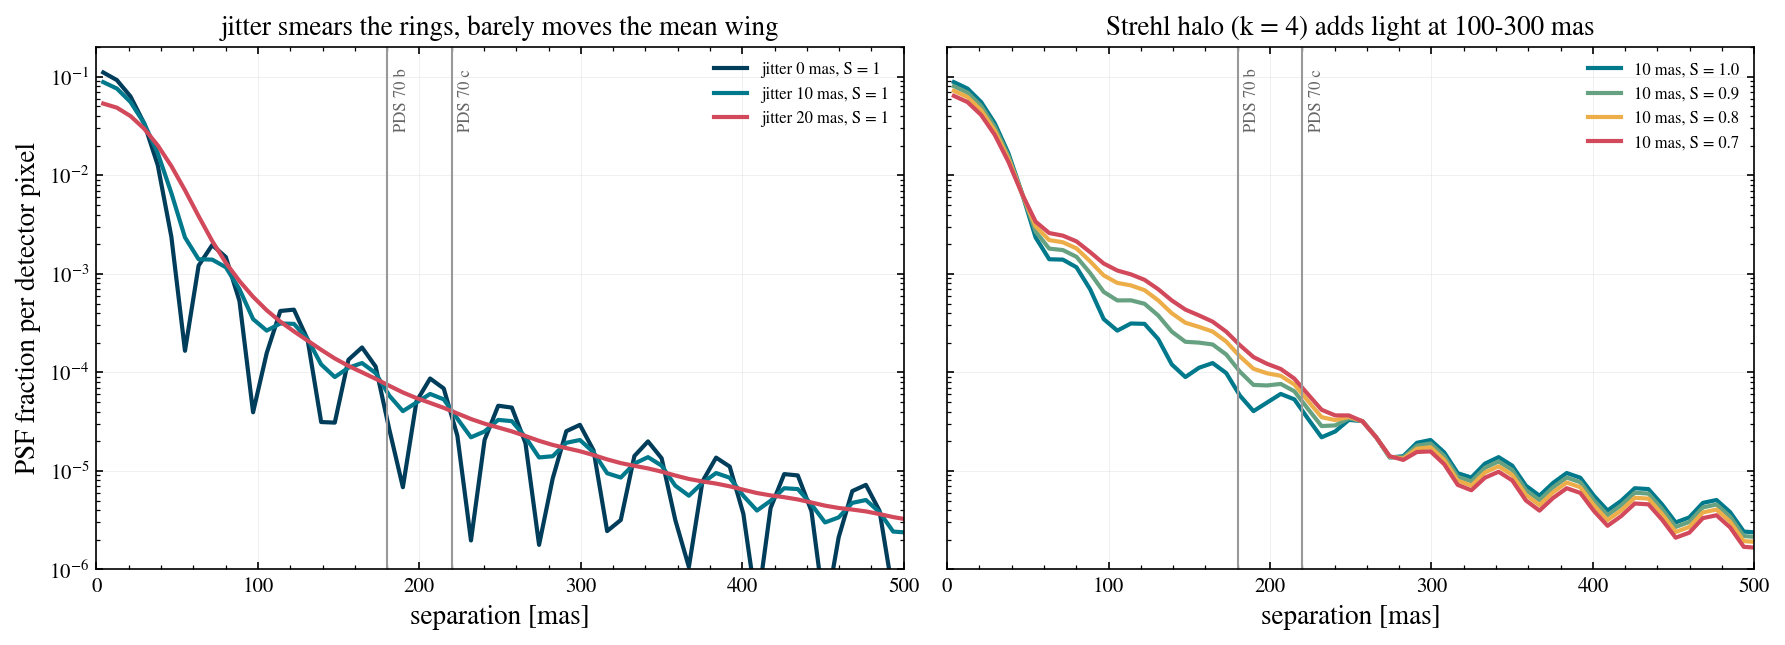

In [2]:
def radial_profile_px(psf_fine, plate_mas, dr_px=0.5):
    n = psf_fine.shape[0]; c = (n - 1) / 2
    yy, xx = np.mgrid[:n, :n]
    r = np.hypot(xx - c, yy - c) / OVERSAMPLE
    edges = np.arange(0, r.max(), dr_px)
    idx = np.digitize(r.ravel(), edges) - 1
    p = psf_fine.ravel() * OVERSAMPLE ** 2
    prof = np.bincount(idx, weights=p, minlength=edges.size) / np.maximum(np.bincount(idx, minlength=edges.size), 1)
    return (edges[:-1] + dr_px / 2) * plate_mas, prof[:-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for j, col in zip([0.0, 10.0, 20.0], [DBLUE, TEAL, RED]):
    r, p = radial_profile_px(inst.fine_psf(j, 1.0), inst.plate_mas)
    axes[0].plot(r, p, color=col, label=f'jitter {j:.0f} mas, S = 1')
for s in STREHLS:
    r, p = radial_profile_px(inst.fine_psf(REQ_JIT, s), inst.plate_mas)
    axes[1].plot(r, p, color=SCOL[s], label=f'10 mas, S = {s}')
for ax in axes:
    for name, pl in PLANETS.items():
        ax.axvline(pl['sep_mas'], color='0.6', lw=1); ax.text(pl['sep_mas'] + 4, 3e-2, f'PDS 70 {name}', fontsize=8, rotation=90, color='0.4')
    ax.set_yscale('log'); ax.set_ylim(1e-6, 0.2); ax.set_xlim(0, 500); ax.set_xlabel('separation [mas]'); ax.legend(fontsize=8)
axes[0].set_ylabel('PSF fraction per detector pixel')
axes[0].set_title('jitter smears the rings, barely moves the mean wing'); axes[1].set_title(f'Strehl halo (k = {HALO_K:.0f}) adds light at 100-300 mas')
fig.tight_layout(); savefig(fig, 'fig06_js_profiles')

print('stellar light in a 2 px aperture at 180 mas, relative to (10 mas, S = 1), and peak-pixel fraction:')
s0, _ = aperture_fractions(inst, inst.fine_psf(REQ_JIT, 1.0), [180.0], R_AP)
for j, s in [(0, 1.0), (10, 1.0), (20, 1.0), (10, 0.9), (10, 0.8), (10, 0.7), (20, 0.7)]:
    sf, _ = aperture_fractions(inst, inst.fine_psf(j, s), [180.0], R_AP)
    print(f'  jitter {j:2d} mas, S = {s}: x{sf[0] / s0[0]:.2f}, peak fraction {inst.peak_fraction(j, s):.3f}, '
          f'frame time {inst.frame_time(j, s):.1f} s')

## 2. Static effect: the photon-noise limit across the grid

5σ line-flux limit in 1 h (ideal subtraction) at 100, 180 and 300 mas, 2 nm filter, PDS 70 host. The
aperture is re-optimised at every grid point.

36 grid points in 11 s


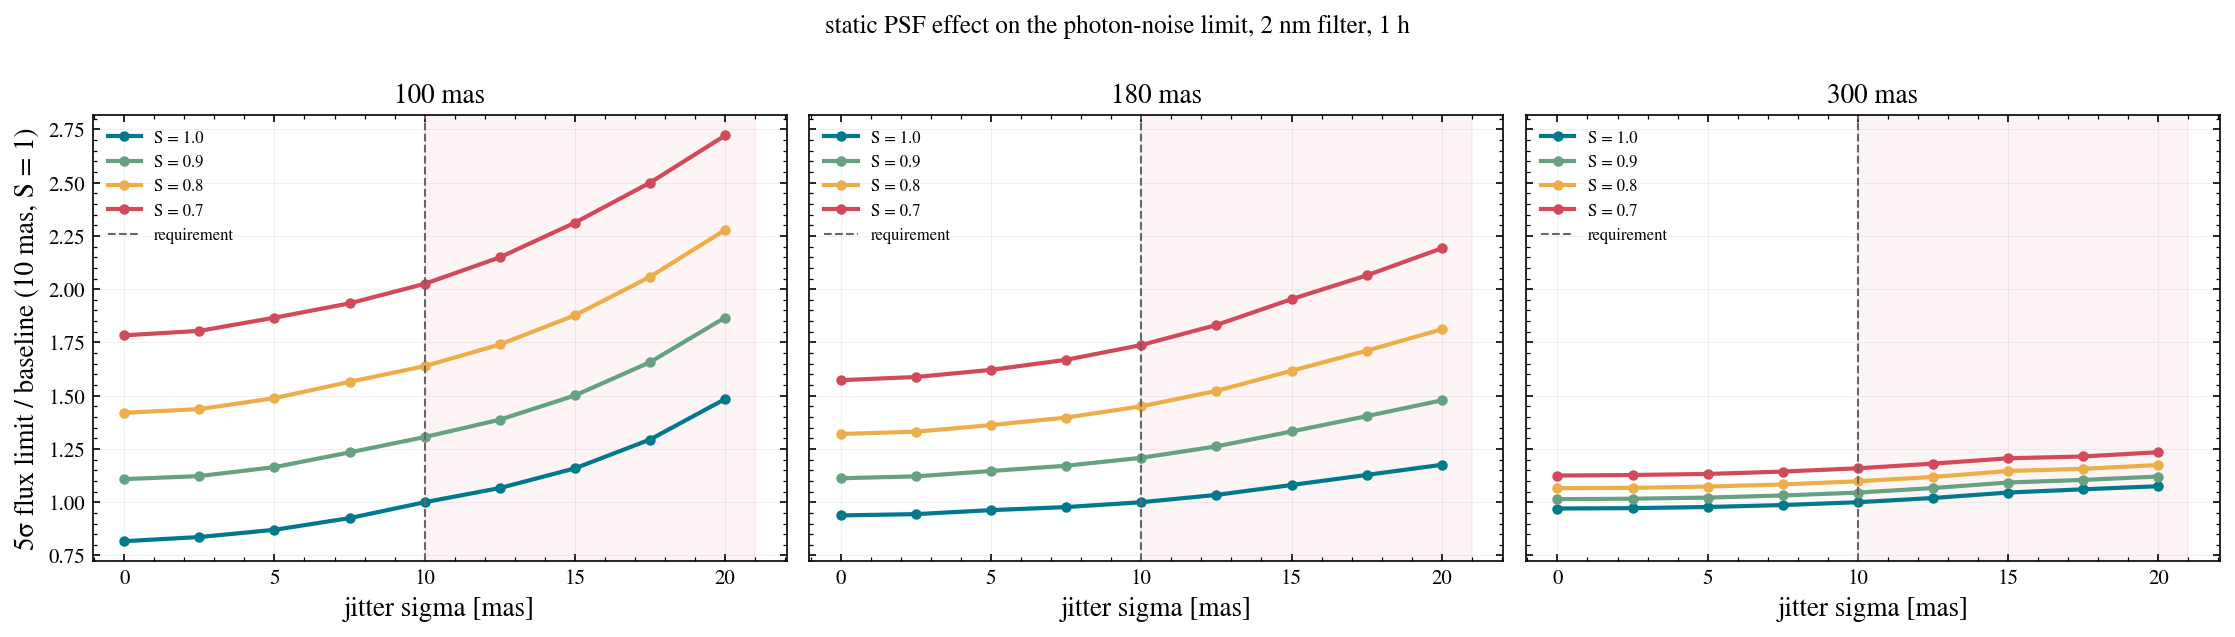

In [3]:
t0 = time.time()
rows = []
LIM = np.empty((JITTERS.size, STREHLS.size, len(SEPS_KEY)))
per_1e16 = inst.line_rate(1e-16) / inst.star_rate
for i, j in enumerate(JITTERS):
    for k, s in enumerate(STREHLS):
        cc = contrast_curve(inst, j, s, SEPS_KEY, T_TOT)
        LIM[i, k] = cc['contrast'] / per_1e16 * 1e-16
        for m, sep in enumerate(SEPS_KEY):
            rows.append(dict(jitter=j, strehl=s, sep_mas=sep, flux_lim_5sig_1h=LIM[i, k, m], r_ap_px=cc['r_ap_px'][m],
                             t_frame_s=cc['t_frame_s'], n_frames=cc['n_frames']))
STATIC = Table(rows); STATIC['flux_lim_5sig_1h'].format = '%.3e'
STATIC.write(os.path.join(OUT, 'js_static_fluxlimit.ecsv'), format='ascii.ecsv', overwrite=True)
iJ0, iS0 = int(np.flatnonzero(JITTERS == REQ_JIT)[0]), 0
print(f'{JITTERS.size * STREHLS.size} grid points in {time.time() - t0:.0f} s')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (m, sep) in zip(axes, enumerate(SEPS_KEY)):
    for k, s in enumerate(STREHLS):
        ax.plot(JITTERS, LIM[:, k, m] / LIM[iJ0, iS0, m], 'o-', ms=4, color=SCOL[s], label=f'S = {s}')
    req_lines(ax); ax.axvspan(REQ_JIT, 21, color=RED, alpha=0.06)
    ax.set_xlabel('jitter sigma [mas]'); ax.set_title(f'{sep:.0f} mas'); ax.legend(fontsize=8)
axes[0].set_ylabel('5σ flux limit / baseline (10 mas, S = 1)')
fig.suptitle('static PSF effect on the photon-noise limit, 2 nm filter, 1 h', y=1.0)
fig.tight_layout(); savefig(fig, 'fig07_js_static_ratio')

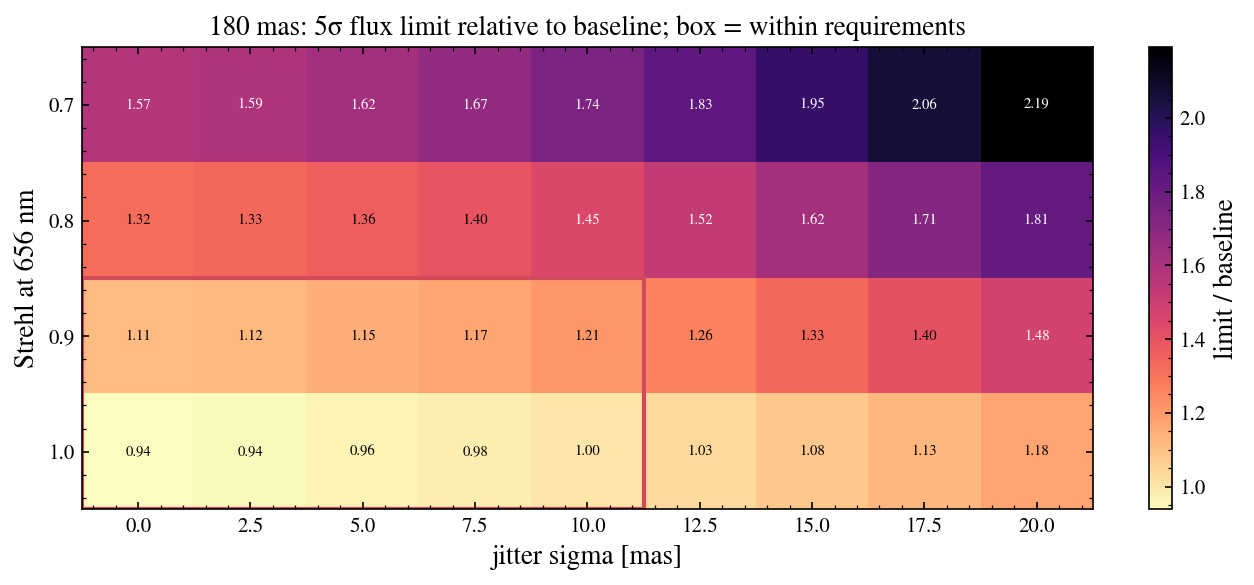

In [4]:
def heatmap(ax, Z, title, fmt='{:.2f}', cmap='magma_r', cbar_label='', vmin=None, vmax=None):
    n_j0 = int(np.sum(JITTERS <= REQ_JIT)); n_s8 = int(np.sum(STREHLS >= S_REQ))
    im = ax.imshow(Z.T, origin='lower', aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                   extent=[-0.5, JITTERS.size - 0.5, -0.5, STREHLS.size - 0.5])
    ax.set_xticks(range(JITTERS.size)); ax.set_xticklabels([f'{j:.1f}' for j in JITTERS])
    ax.set_yticks(range(STREHLS.size)); ax.set_yticklabels([f'{s:.1f}' for s in STREHLS])
    ax.set_xlabel('jitter sigma [mas]'); ax.set_ylabel('Strehl at 656 nm'); ax.set_title(title)
    for i in range(JITTERS.size):
        for k in range(STREHLS.size):
            rgb = im.cmap(im.norm(Z[i, k]))[:3]; lum = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
            ax.text(i, k, fmt.format(Z[i, k]), ha='center', va='center', fontsize=7, color='w' if lum < 0.5 else 'k')
    ax.add_patch(plt.Rectangle((-0.5, -0.5), n_j0, n_s8, fill=False, ec=RED, lw=2))
    ax.grid(False); plt.colorbar(im, ax=ax, label=cbar_label, fraction=0.046)

fig, ax = plt.subplots(figsize=(8.5, 4))
heatmap(ax, LIM[:, :, 1] / LIM[iJ0, iS0, 1], '180 mas: 5σ flux limit relative to baseline; box = within requirements',
        cbar_label='limit / baseline')
fig.tight_layout(); savefig(fig, 'fig08_js_static_heatmap')

## 3. Subtraction mismatch: the systematic floor

Residual $5\,|{\rm PSF}_{\rm sci} - {\rm PSF}_{\rm ref}|_{\rm ap} / {\rm EE}_{\rm ap}$ as a planet/star flux ratio, in a
2 px aperture. Because the residual of smeared Airy rings changes sign across a ring, it is taken as the RMS
over one Airy FWHM (45 mas) of separation around the quoted value, i.e. the typical floor a planet at an
unknown phase of the ring pattern sees. Two drivers:

* **jitter mismatch**: the reference sequence has jitter $\sigma_{\rm ref} = (1+\delta)\,\sigma_{\rm sci}$, with
  $\delta$ = 10, 20 and 50%. For a Gaussian blur the residual scales with the difference of the variances,
  $\sigma_{\rm ref}^2 - \sigma_{\rm sci}^2 \approx 2\delta\sigma^2$, so at fixed $\delta$ the floor grows roughly as the
  *square* of the jitter (steeper where the rings are still sharp): halving the jitter buys a factor of four
  or more.
* **Strehl drift**: the reference has $S_{\rm ref} = S_{\rm sci} + \Delta S$ with $\Delta S$ = 0.01, 0.02 and 0.05
  (a 0.02 drift at $S = 0.8$ is ~2.5 nm RMS of wavefront change; thermal breathing of a 3 m telescope can
  do that). The residual is $\Delta S \times$ (halo minus core) and does not depend much on $S$ itself.

Horizontal lines: the PDS 70 b and c planet/star ratios in each filter. Because the floor is a ratio while the
planets' ratio scales as 1/bandwidth, the narrow filter buys its full 10x here.

mismatch grid in 51 s


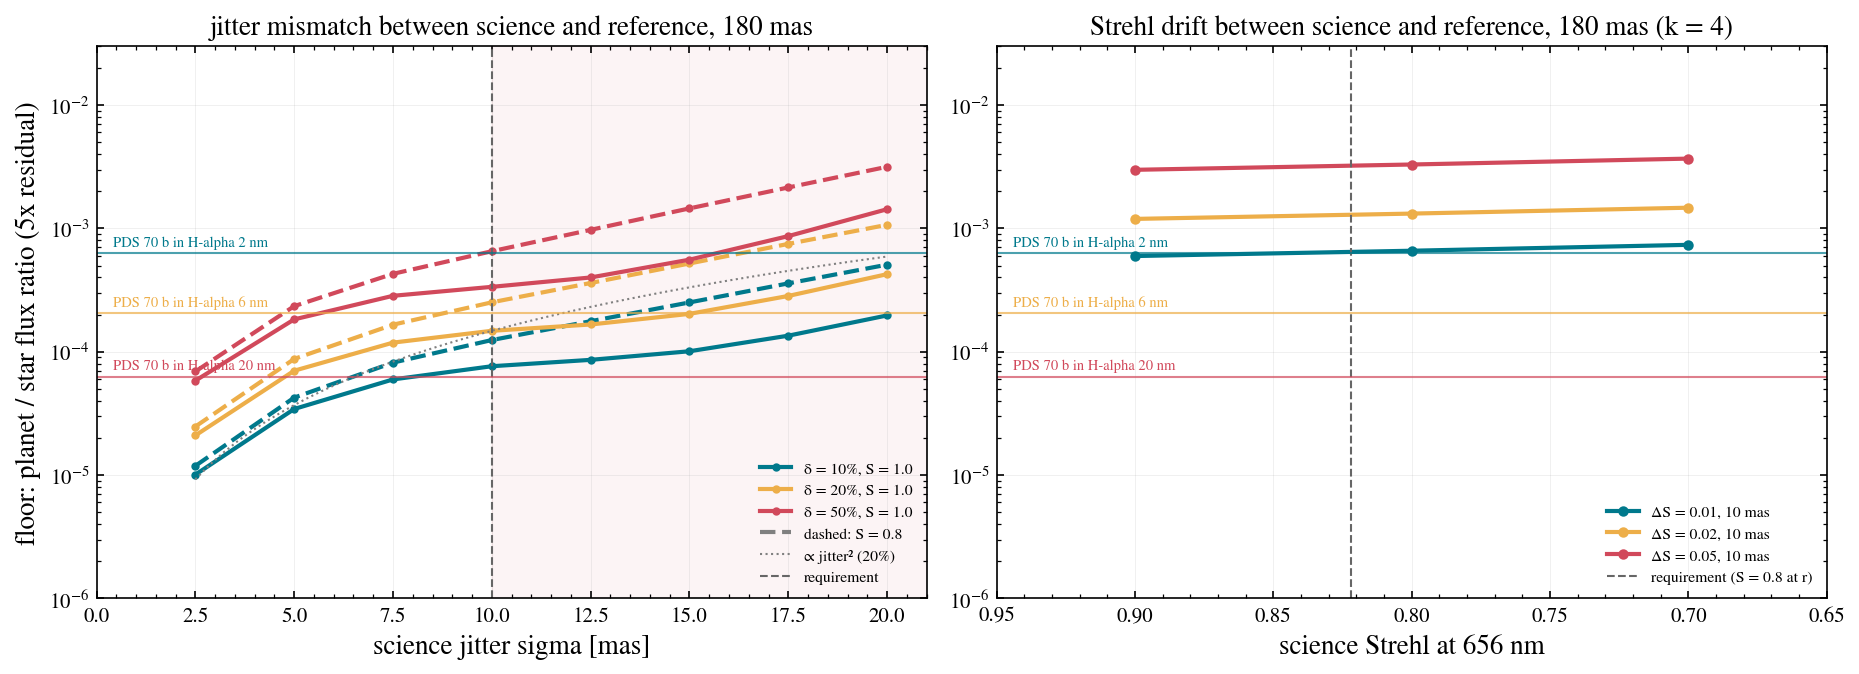

In [5]:
DELTAS = [0.1, 0.2, 0.5]
DSS = [0.01, 0.02, 0.05]
t0 = time.time()
rows = []
FLOOR_J = np.empty((len(DELTAS), JITTERS.size, STREHLS.size, len(SEPS_KEY)))
FLOOR_S = np.empty((len(DSS), JITTERS.size, STREHLS.size, len(SEPS_KEY)))
for i, j in enumerate(JITTERS):
    for k, s in enumerate(STREHLS):
        for d_i, d in enumerate(DELTAS):
            FLOOR_J[d_i, i, k] = mismatch_floor(inst, j, j * (1 + d), s, s, SEPS_KEY, R_AP)
        for d_i, ds in enumerate(DSS):
            FLOOR_S[d_i, i, k] = mismatch_floor(inst, j, j, s, min(s + ds, 1.0), SEPS_KEY, R_AP)
        for m, sep in enumerate(SEPS_KEY):
            row = dict(jitter=j, strehl=s, sep_mas=sep)
            row.update({f'floor_jit_{int(d * 100)}pct': FLOOR_J[d_i, i, k, m] for d_i, d in enumerate(DELTAS)})
            row.update({f'floor_dS_{ds}': FLOOR_S[d_i, i, k, m] for d_i, ds in enumerate(DSS)})
            rows.append(row)
FLOOR = Table(rows)
for c in FLOOR.colnames[3:]: FLOOR[c].format = '%.3e'
FLOOR.write(os.path.join(OUT, 'js_mismatch_floor.ecsv'), format='ascii.ecsv', overwrite=True)
print(f'mismatch grid in {time.time() - t0:.0f} s')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax = axes[0]; m = 1   # 180 mas
for d_i, d in enumerate(DELTAS):
    for s, ls in [(1.0, '-'), (0.8, '--')]:
        k = int(np.flatnonzero(STREHLS == s)[0])
        ax.plot(JITTERS[1:], FLOOR_J[d_i, 1:, k, m], ls, color=[TEAL, AMBER, RED][d_i], marker='o', ms=3,
                label=f'δ = {d:.0%}, S = {s}' if ls == '-' else None)
ax.plot([], [], '--', color='0.5', label='dashed: S = 0.8')
jj = np.linspace(2.5, 20, 50); k1 = int(np.flatnonzero(STREHLS == 1.0)[0])
ax.plot(jj, FLOOR_J[1, iJ0, k1, m] * (jj / REQ_JIT) ** 2, ':', color='0.5', lw=1, label='∝ jitter² (20%)')
req_lines(ax); ax.axvspan(REQ_JIT, 21, color=RED, alpha=0.06)
ax.set_yscale('log'); ax.set_xlim(0, 21); ax.set_ylim(1e-6, 3e-2)
ax.set_xlabel('science jitter sigma [mas]'); ax.set_ylabel('floor: planet / star flux ratio (5x residual)')
ax.set_title('jitter mismatch between science and reference, 180 mas'); ax.legend(fontsize=7.5, loc='lower right')
ax = axes[1]
for d_i, ds in enumerate(DSS):
    ax.plot(STREHLS[1:], FLOOR_S[d_i, iJ0, 1:, m], 'o-', ms=4, color=[TEAL, AMBER, RED][d_i], label=f'ΔS = {ds}, 10 mas')
req_lines(ax, jitter=False, strehl=True)
ax.set_yscale('log'); ax.set_xlim(0.95, 0.65); ax.set_ylim(1e-6, 3e-2)
ax.set_xlabel('science Strehl at 656 nm'); ax.set_title(f'Strehl drift between science and reference, 180 mas (k = {HALO_K:.0f})')
ax.legend(fontsize=7.5, loc='lower right')
for ax in axes:
    for f, col in zip(FILTERS, [TEAL, AMBER, RED]):
        ax.axhline(RATIO[f, 'b'], color=col, lw=1, alpha=0.7)
        ax.text(ax.get_xlim()[0] + 0.02 * np.diff(ax.get_xlim())[0], RATIO[f, 'b'] * 1.15, f'PDS 70 b in {FLAB[f]}', fontsize=7, color=col)
fig.tight_layout(); savefig(fig, 'fig09_js_mismatch_floor')

### 3.1 Floor vs separation

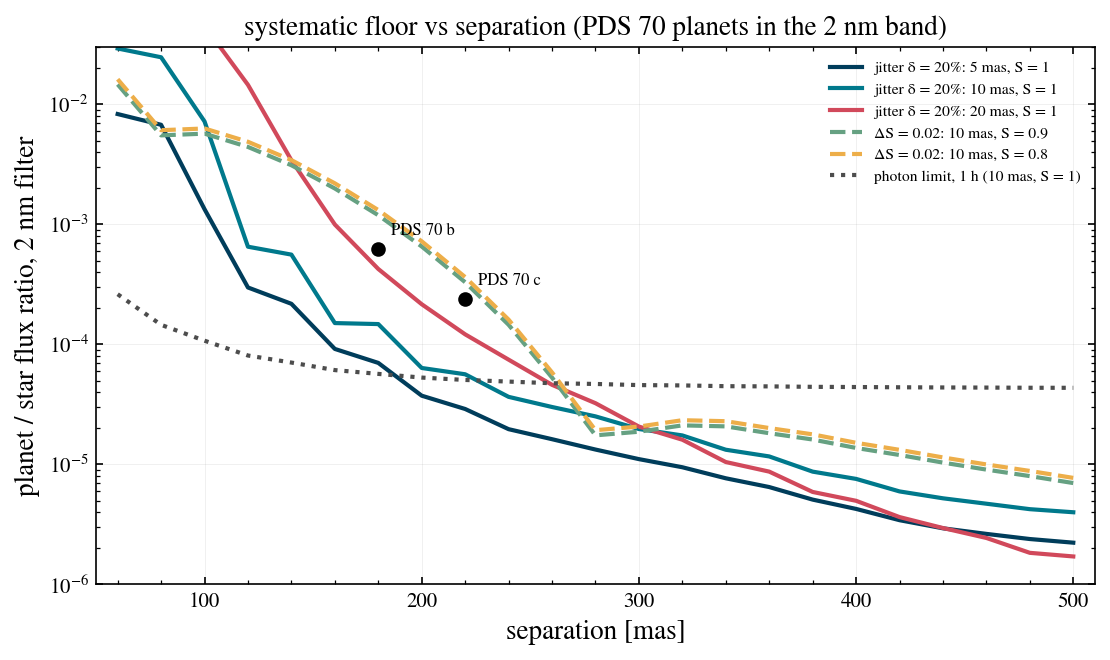

In [6]:
SEPS = np.arange(60.0, 501.0, 20.0)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for j, s, col, lab in [(5.0, 1.0, DBLUE, '5 mas, S = 1'), (10.0, 1.0, TEAL, '10 mas, S = 1'), (20.0, 1.0, RED, '20 mas, S = 1')]:
    ax.plot(SEPS, mismatch_floor(inst, j, 1.2 * j, s, s, SEPS, R_AP), color=col, label=f'jitter δ = 20%: {lab}')
for s, col in [(0.9, GREEN), (0.8, AMBER)]:
    ax.plot(SEPS, mismatch_floor(inst, 10.0, 10.0, s, s + 0.02, SEPS, R_AP), '--', color=col, label=f'ΔS = 0.02: 10 mas, S = {s}')
ax.plot(SEPS, contrast_curve(inst, REQ_JIT, 1.0, SEPS, T_TOT)['contrast'], ':', color='0.3', label='photon limit, 1 h (10 mas, S = 1)')
for name, pl in PLANETS.items():
    ax.plot(pl['sep_mas'], RATIO['zwo:halpha2', name], 'o', color='k', ms=6); ax.text(pl['sep_mas'] + 6, RATIO['zwo:halpha2', name] * 1.3, f'PDS 70 {name}', fontsize=8)
ax.set_yscale('log'); ax.set_ylim(1e-6, 3e-2); ax.set_xlim(50, 510)
ax.set_xlabel('separation [mas]'); ax.set_ylabel('planet / star flux ratio, 2 nm filter')
ax.set_title('systematic floor vs separation (PDS 70 planets in the 2 nm band)'); ax.legend(fontsize=7.5, loc='upper right')
fig.tight_layout(); savefig(fig, 'fig10_js_floor_vs_sep')

### 3.2 Halo-width assumption

The Strehl model's one free shape parameter is $k$ (halo FWHM in Airy FWHM). $k = 4$ puts the halo's
half-light radius at ~90 mas so it feeds the 100-300 mas zone directly; $k = 2$ keeps it closer in, $k = 8$
spreads it thinner. This bounds how much the Strehl conclusions depend on the choice.

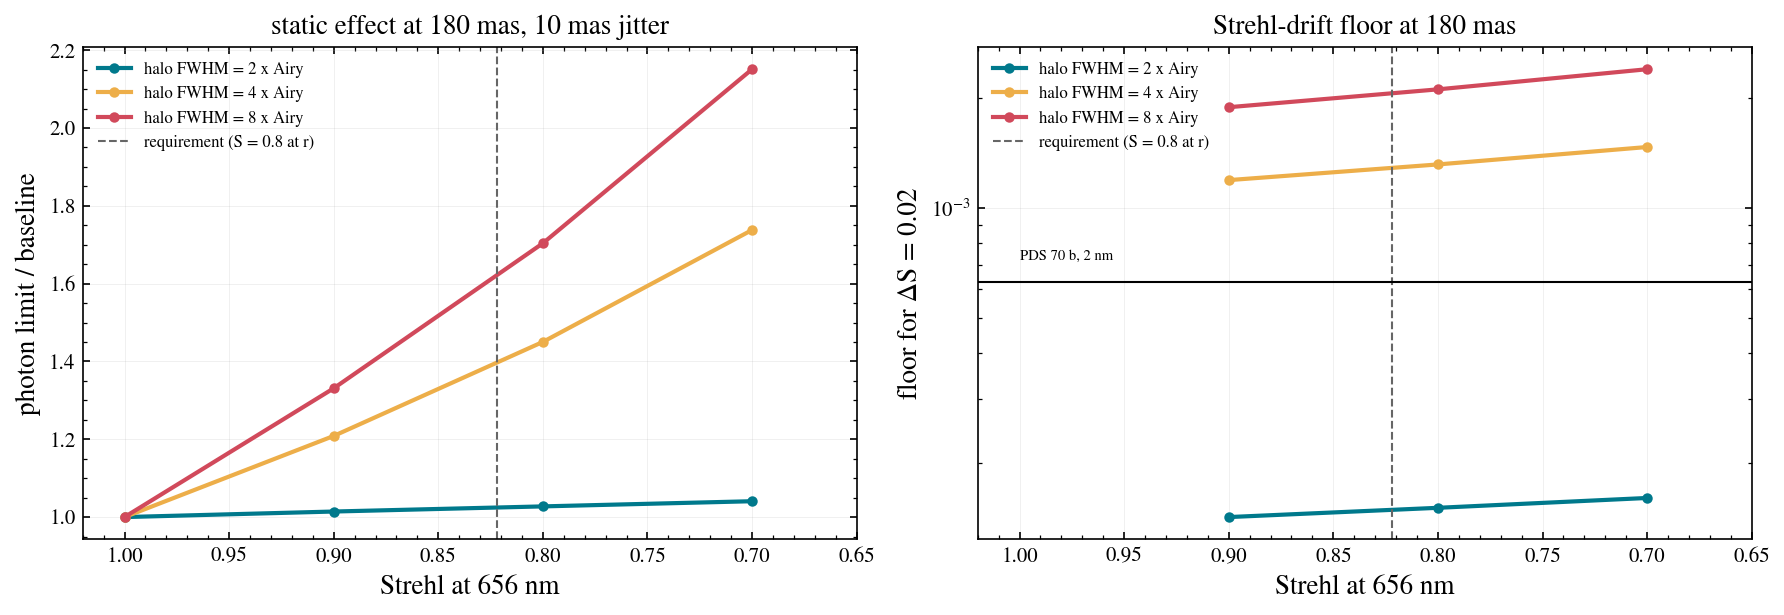

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for kk, col in zip([2.0, 4.0, 8.0], [TEAL, AMBER, RED]):
    lim = np.array([contrast_curve(inst, REQ_JIT, s, [180.0], T_TOT, halo_k=kk)['contrast'][0] for s in STREHLS])
    base = contrast_curve(inst, REQ_JIT, 1.0, [180.0], T_TOT)['contrast'][0]
    axes[0].plot(STREHLS, lim / base, 'o-', ms=4, color=col, label=f'halo FWHM = {kk:.0f} x Airy')
    fl = np.array([mismatch_floor(inst, REQ_JIT, REQ_JIT, s, min(s + 0.02, 1.0), [180.0], R_AP, halo_k=kk)[0] for s in STREHLS[1:]])
    axes[1].plot(STREHLS[1:], fl, 'o-', ms=4, color=col, label=f'halo FWHM = {kk:.0f} x Airy')
for ax in axes:
    req_lines(ax, jitter=False, strehl=True); ax.set_xlim(1.02, 0.65); ax.set_xlabel('Strehl at 656 nm'); ax.legend(fontsize=8)
axes[0].set_ylabel('photon limit / baseline'); axes[0].set_title('static effect at 180 mas, 10 mas jitter')
axes[1].set_yscale('log'); axes[1].set_ylabel('floor for ΔS = 0.02'); axes[1].set_title('Strehl-drift floor at 180 mas')
axes[1].axhline(RATIO['zwo:halpha2', 'b'], color='k', lw=1); axes[1].text(1.0, RATIO['zwo:halpha2', 'b'] * 1.15, 'PDS 70 b, 2 nm', fontsize=7)
fig.tight_layout(); savefig(fig, 'fig11_js_halo_k')

## 4. Putting it together: what limits PDS 70 b at each grid point

For each (jitter, Strehl) the detectable line flux at 180 mas in 1 h is the larger of the photon limit and the
two systematic floors (jitter mismatch $\delta$ = 20%, Strehl drift $\Delta S$ = 0.02), converted to flux with
the PDS 70 host in the 2 nm filter. The heatmap shows that flux relative to PDS 70 b's nominal
$8.1\times10^{-16}$: values below 1 mean a 5σ detection.

corner cases at 180 mas (2 nm filter, PDS 70 host, 1 h):
 jitter     S     photon  jit-mismatch    S-drift  limit/F_b
    0.0  1.00   6.88e-17      0.00e+00   0.00e+00       0.08
   10.0  1.00   7.33e-17      1.91e-16   0.00e+00       0.24
   10.0  0.80   1.06e-16      3.25e-16   1.70e-15       2.10
   20.0  1.00   8.62e-17      5.49e-16   0.00e+00       0.68
   20.0  0.80   1.33e-16      1.38e-15   2.43e-15       3.00
   20.0  0.70   1.61e-16      1.94e-15   2.69e-15       3.32


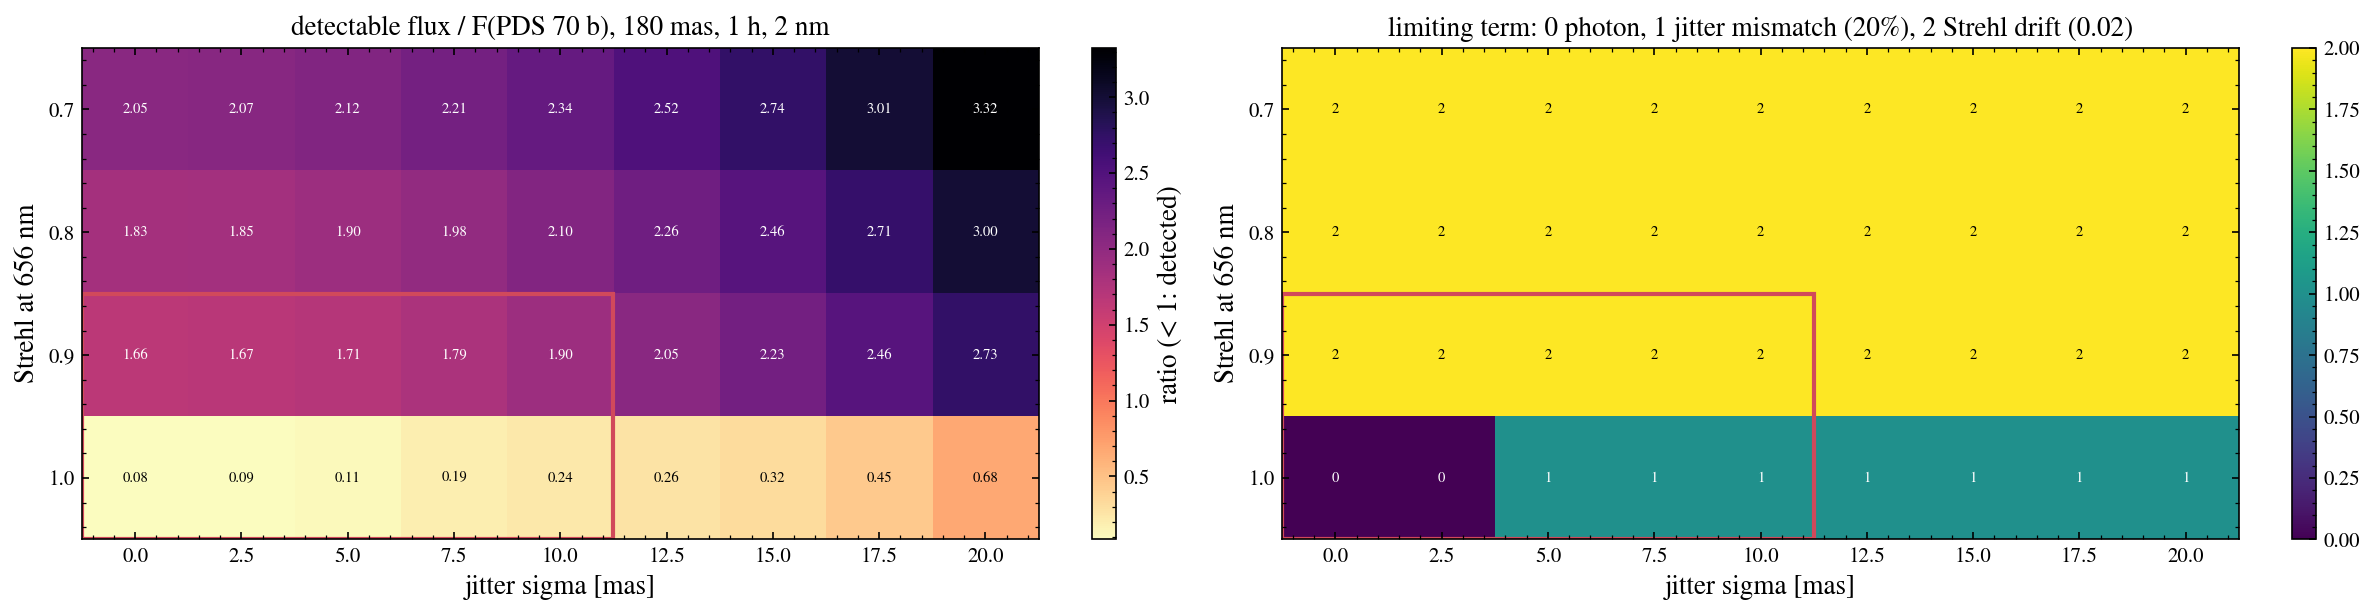

In [8]:
m = 1; d20 = DELTAS.index(0.2); ds02 = DSS.index(0.02)
photon = LIM[:, :, m]
flo_j = FLOOR_J[d20, :, :, m] / per_1e16 * 1e-16
flo_s = FLOOR_S[ds02, :, :, m] / per_1e16 * 1e-16
worst = np.maximum.reduce([photon, flo_j, flo_s])
which = np.argmax(np.stack([photon, flo_j, flo_s]), axis=0)
fig, axes = plt.subplots(1, 2, figsize=(16, 4.2))
heatmap(axes[0], worst / PLANETS['b']['flux'], 'detectable flux / F(PDS 70 b), 180 mas, 1 h, 2 nm', cbar_label='ratio (< 1: detected)')
heatmap(axes[1], which.astype(float), 'limiting term: 0 photon, 1 jitter mismatch (20%), 2 Strehl drift (0.02)', fmt='{:.0f}',
        cmap='viridis', vmin=0, vmax=2, cbar_label='')
fig.tight_layout(); savefig(fig, 'fig12_js_combined')

print('corner cases at 180 mas (2 nm filter, PDS 70 host, 1 h):')
print(f"{'jitter':>7s} {'S':>5s} {'photon':>10s} {'jit-mismatch':>13s} {'S-drift':>10s} {'limit/F_b':>10s}")
for j, s in [(0.0, 1.0), (10.0, 1.0), (10.0, 0.8), (20.0, 1.0), (20.0, 0.8), (20.0, 0.7)]:
    i = int(np.flatnonzero(JITTERS == j)[0]); k = int(np.flatnonzero(STREHLS == s)[0])
    print(f'{j:7.1f} {s:5.2f} {photon[i, k]:10.2e} {flo_j[i, k]:13.2e} {flo_s[i, k]:10.2e} {worst[i, k] / PLANETS["b"]["flux"]:10.2f}')

## 5. Summary

* **Static PSF changes are a modest effect.** Across jitter 0-20 mas and Strehl 1.0-0.7 the photon-noise
  limit at 180 mas moves by a factor 0.9-2.2 (section 2): the Airy wing is already the dominant light there,
  jitter only redistributes it between the rings, and a Strehl halo of the assumed width adds to it (x2.3 in
  aperture at S = 0.8). Lower Strehl and higher jitter also lower the peak and so *lengthen* the frames,
  which partly compensates in the read-noise term. At the requirement corner the photon limit for PDS 70 b
  is still ~8x below its flux in 1 h.
* **PSF stability is the real requirement, and it is what fails first.**
  - *Jitter mismatch*: a 20% jitter difference between science and reference at 10 mas gives a floor well
    below PDS 70 b in the 2 nm band (a quarter of its flux); at 20 mas it is ~3x higher and reaches two
    thirds of the planet's flux, and with S = 0.8 on top it exceeds the planet. It scales as jitter² or
    steeper.
  - *Strehl drift*: a change of 0.02 in Strehl (~2.5 nm RMS of wavefront) between science and reference
    puts the floor *above* PDS 70 b (2.1x its flux at the requirement corner, with the 5x margin used here;
    the raw residual is ~2.4x below the planet). This does not depend on the mean Strehl, but it depends
    strongly on *where* the scattered light lands: with a halo half the assumed width (k = 2) the floor
    drops 20x and is harmless. The quantity that matters is therefore the mid-spatial-frequency wavefront
    stability (scales ~D/4, which scatter light to 100-300 mas), not the Strehl budget as a number.
  - Both floors are ratios of the stellar light, so the 2 nm filter beats the 20 nm filter by the full
    factor 10 here. That, not the photon limit, is the reason to prefer it.
* **Requirement corner (10 mas, S = 0.82 at H-alpha).** PDS 70 b and c are photon-limited detections within
  1 h if the PSF repeats; a 20% jitter change is tolerable, a 0.02 Strehl change is not (for the k = 4 halo).
  Numbers: table above and `halpha_hci_out/js_*.ecsv`.
* **What to ask engineering for:** not a lower jitter or higher Strehl per se, but (i) jitter and
  mid-spatial-frequency wavefront *repeatability* between science and reference sequences (or a reference
  taken in the same thermal state, or the ability to roll the spacecraft for ADI), and (ii) a bound on
  near-core scattered light inside 1", which no current model provides.

**Caveats.** The floors are for one mismatch parameter at a time with a coherent 5x margin; real
residuals combine several and are partly averaged by roll or by many references, so these are indicative
levels rather than a pipeline forecast. The Strehl halo is a single Gaussian of assumed width (section 3.2
bounds that). Ideal, noise-free reference; static, monochromatic, unobscured Airy PSF; no near-core
scatter beyond the flat FRED floor.